In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

matches_df = pd.read_csv("../data/processed/matches.csv")
matches_df["date"] = pd.to_datetime(matches_df["date"])

matches_df.shape
deliveries_df = pd.read_csv("../data/processed/deliveries.csv")


In [2]:
matches_df.groupby("has_impact_player_rule")[["total_runs_inn1", "total_runs_inn2"]].mean().round(1)

,total_runs_inn1,total_runs_inn2
has_impact_player_rule,,
False,162.4,149.3
True,188.5,174.3


In [3]:
def get_bat_first(row):
    if row["toss_decision"] == "bat":
        return row["toss_winner"]
    else:
        # toss winner chose to field, so the OTHER team bats first
        return row["team2"] if row["toss_winner"] == row["team1"] else row["team1"]

matches_df["bat_first_team"] = matches_df.apply(get_bat_first, axis=1)
matches_df["bat_second_team"] = matches_df.apply(
    lambda row: row["team2"] if row["bat_first_team"] == row["team1"] else row["team1"],
    axis=1
)

matches_df[["team1", "team2", "toss_winner", "toss_decision", "bat_first_team", "bat_second_team"]].head()

,team1,team2,toss_winner,toss_decision,bat_first_team,bat_second_team
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,Royal Challengers Bengaluru
1,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,Punjab Kings
2,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,Delhi Capitals
3,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,Kolkata Knight Riders
4,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Mumbai Indians,Royal Challengers Bengaluru


In [4]:
season_trend = matches_df.groupby("season")[["total_runs_inn1", "total_runs_inn2"]].mean().round(1)
season_trend

,total_runs_inn1,total_runs_inn2
season,,
2008,161.0,148.3
2009,150.3,136.1
2010,164.8,149.6
2011,152.4,139.3
2012,157.5,145.9
2013,155.9,140.7
2014,163.1,152.1
2015,166.3,146.9
2016,162.6,151.8


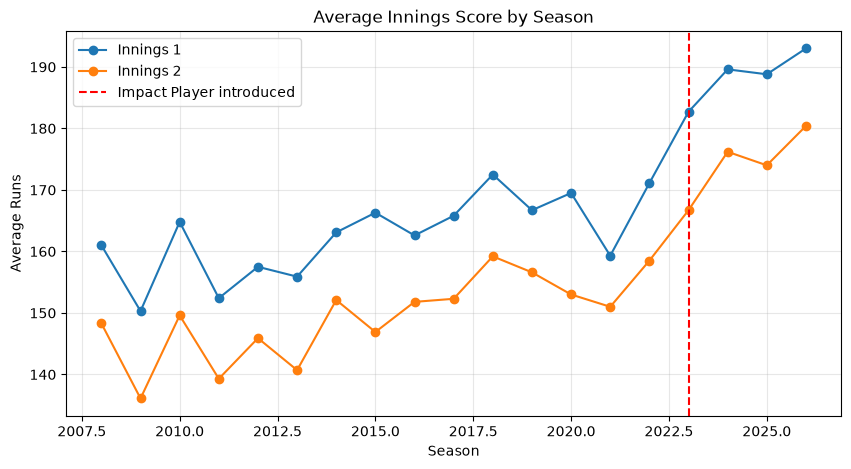

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(season_trend.index, season_trend["total_runs_inn1"], marker="o", label="Innings 1")
plt.plot(season_trend.index, season_trend["total_runs_inn2"], marker="o", label="Innings 2")
plt.axvline(x=2023, color="red", linestyle="--", label="Impact Player introduced")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.title("Average Innings Score by Season")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
matches_df.groupby("has_impact_player_rule")[["death_runs_inn1", "death_runs_inn2"]].mean().round(1)

,death_runs_inn1,death_runs_inn2
has_impact_player_rule,,
False,40.2,27.7
True,43.9,29.1


In [7]:
matches_df.groupby("season")[["death_runs_inn1", "death_runs_inn2"]].mean().round(1)


,death_runs_inn1,death_runs_inn2
season,,
2008,39.4,22.7
2009,37.0,26.6
2010,42.1,26.3
2011,35.1,24.0
2012,39.0,29.0
2013,41.4,27.0
2014,39.2,30.2
2015,40.8,28.4
2016,39.5,26.8


In [8]:
matches_df.groupby("has_impact_player_rule")[["boundary_pct_inn1", "boundary_pct_inn2", "dot_pct_inn1", "dot_pct_inn2"]].mean().round(2)

,boundary_pct_inn1,boundary_pct_inn2,dot_pct_inn1,dot_pct_inn2
has_impact_player_rule,,,,
False,16.08,16.11,34.64,35.72
True,19.97,20.47,31.08,32.29


In [9]:
matches_df.groupby("season")[["pp_runs_inn1", "mid_runs_inn1", "death_runs_inn1"]].mean().round(1)

,pp_runs_inn1,mid_runs_inn1,death_runs_inn1
season,,,
2008,44.9,76.7,39.4
2009,44.0,69.2,37.0
2010,47.0,75.7,42.1
2011,41.9,75.4,35.1
2012,42.7,75.8,39.0
2013,41.0,73.4,41.4
2014,44.3,79.5,39.2
2015,47.0,78.4,40.8
2016,43.9,79.2,39.5


In [10]:
era_summary = matches_df.groupby("has_impact_player_rule").agg(
    avg_runs_inn1=("total_runs_inn1", "mean"),
    avg_runs_inn2=("total_runs_inn2", "mean"),
    avg_pp_runs_inn1=("pp_runs_inn1", "mean"),
    avg_mid_runs_inn1=("mid_runs_inn1", "mean"),
    avg_death_runs_inn1=("death_runs_inn1", "mean"),
    avg_wickets_inn1=("wickets_inn1", "mean"),
    avg_wickets_inn2=("wickets_inn2", "mean"),
    avg_boundary_pct_inn1=("boundary_pct_inn1", "mean"),
    avg_boundary_pct_inn2=("boundary_pct_inn2", "mean"),
    avg_dot_pct_inn1=("dot_pct_inn1", "mean"),
    avg_fours_inn1=("fours_inn1", "mean"),
    avg_sixes_inn1=("sixes_inn1", "mean"),
).round(2)

era_summary

,avg_runs_inn1,avg_runs_inn2,avg_pp_runs_inn1,avg_mid_runs_inn1,avg_death_runs_inn1,avg_wickets_inn1,avg_wickets_inn2,avg_boundary_pct_inn1,avg_boundary_pct_inn2,avg_dot_pct_inn1,avg_fours_inn1,avg_sixes_inn1
has_impact_player_rule,,,,,,,,,,,,
False,162.41,149.28,45.06,77.16,40.19,6.09,5.63,16.08,16.11,34.64,13.86,5.91
True,188.54,174.29,56.03,88.60,43.90,6.27,5.93,19.97,20.47,31.08,15.67,9.18


In [11]:
import numpy as np

matches_df["balls_per_boundary_inn1"] = (matches_df["total_balls_inn1"] / (matches_df["fours_inn1"] + matches_df["sixes_inn1"])).round(2)
matches_df["balls_per_wicket_inn1"] = (matches_df["total_balls_inn1"] / matches_df["wickets_inn1"].replace(0, np.nan)).round(2)

matches_df.groupby("has_impact_player_rule")[["balls_per_boundary_inn1", "balls_per_wicket_inn1"]].mean().round(2)

,balls_per_boundary_inn1,balls_per_wicket_inn1
has_impact_player_rule,,
False,6.90,23.73
True,5.43,23.15


In [12]:
deliveries_df = pd.read_csv("../data/processed/deliveries.csv")
deliveries_df.shape

(295732, 23)

In [13]:
# get the first ball each batter appears on, per match+innings — that determines batting order
batting_order = (
    deliveries_df
    .sort_values(["match_id", "innings", "over", "ball"])
    .drop_duplicates(subset=["match_id", "innings", "batter"], keep="first")
    [["match_id", "innings", "batter"]]
)

batting_order["position"] = batting_order.groupby(["match_id", "innings"]).cumcount() + 1

batting_order.head(15)

,match_id,innings,batter,position
140614,335982,1,SC Ganguly,1
140615,335982,1,BB McCullum,2
140648,335982,1,RT Ponting,3
140696,335982,1,DJ Hussey,4
140722,335982,1,Mohammad Hafeez,5
140738,335982,2,R Dravid,1
140739,335982,2,W Jaffer,2
140746,335982,2,V Kohli,3
140753,335982,2,JH Kallis,4
140769,335982,2,CL White,5


In [14]:
def position_to_role(pos):
    if pos <= 2:
        return "opener"
    elif pos <= 5:
        return "middle_order"
    else:
        return "lower_order"

batting_order["role"] = batting_order["position"].apply(position_to_role)
batting_order.head(15)

,match_id,innings,batter,position,role
140614,335982,1,SC Ganguly,1,opener
140615,335982,1,BB McCullum,2,opener
140648,335982,1,RT Ponting,3,middle_order
140696,335982,1,DJ Hussey,4,middle_order
140722,335982,1,Mohammad Hafeez,5,middle_order
140738,335982,2,R Dravid,1,opener
140739,335982,2,W Jaffer,2,opener
140746,335982,2,V Kohli,3,middle_order
140753,335982,2,JH Kallis,4,middle_order
140769,335982,2,CL White,5,middle_order


In [15]:
deliveries_df = deliveries_df.merge(
    batting_order[["match_id", "innings", "batter", "position", "role"]],
    on=["match_id", "innings", "batter"],
    how="left"
)

deliveries_df[["match_id", "innings", "batter", "position", "role"]].head(10)

KeyError: "['position', 'role'] not in index"

In [ ]:
deliveries_df = deliveries_df.merge(
    matches_df[["match_id", "has_impact_player_rule", "season"]],
    on="match_id",
    how="left"
)

In [ ]:
deliveries_df["is_four"] = deliveries_df["runs_batter"] == 4
deliveries_df["is_six"] = deliveries_df["runs_batter"] == 6

In [ ]:
deliveries_df["is_dot"] = deliveries_df["runs_total"] == 0

deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)

In [ ]:
role_summary = (
    deliveries_df
    .groupby(["has_impact_player_rule", "role"])
    .agg(
        total_runs=("runs_batter", "sum"),
        total_balls=("ball", "count"),
        boundaries=("is_four", "sum"),
        sixes=("is_six", "sum"),
    )
)

role_summary["strike_rate"] = (role_summary["total_runs"] / role_summary["total_balls"] * 100).round(2)
role_summary["boundary_pct"] = ((role_summary["boundaries"] + role_summary["sixes"]) / role_summary["total_balls"] * 100).round(2)

role_summary

total_runs  total_balls  boundaries  \
has_impact_player_rule role                                                
False                  lower_order        49717        41536        3582   
                       middle_order      124977        99639       10472   
                       opener            106285        84779       11446   
True                   lower_order        20089        15046        1500   
                       middle_order       42968        29788        3542   
                       opener             37493        24944        3905   

                                     sixes  strike_rate  boundary_pct  
has_impact_player_rule role                                            
False                  lower_order    2152       119.70         13.80  
                       middle_order   4877       125.43         15.40  
                       opener         3637       125.37         17.79  
True                   lower_order    1085       133.52         17.18  
                       middle_order   2238       144.25         19.40  
                       opener         1790       150.31         22.83

In [ ]:
team_runs = matches_df.melt(
    id_vars=["has_impact_player_rule"],
    value_vars=["team1", "team2"],
    value_name="team"
)[["has_impact_player_rule", "team"]]

In [ ]:
def get_bat_first(row):
    if row["toss_decision"] == "bat":
        return row["toss_winner"]
    else:
        return row["team2"] if row["toss_winner"] == row["team1"] else row["team1"]

matches_df["bat_first_team"] = matches_df.apply(get_bat_first, axis=1)
matches_df["bat_second_team"] = matches_df.apply(
    lambda row: row["team2"] if row["bat_first_team"] == row["team1"] else row["team1"],
    axis=1
)

In [ ]:
matches_df.to_csv("../data/processed/matches.csv", index=False)

In [ ]:
team_runs_first = matches_df[["bat_first_team", "total_runs_inn1", "has_impact_player_rule", "season"]].rename(
    columns={"bat_first_team": "team", "total_runs_inn1": "runs_scored"}
)

team_runs_second = matches_df[["bat_second_team", "total_runs_inn2", "has_impact_player_rule", "season"]].rename(
    columns={"bat_second_team": "team", "total_runs_inn2": "runs_scored"}
)

team_runs = pd.concat([team_runs_first, team_runs_second], ignore_index=True)
team_runs.head()

,team,runs_scored,has_impact_player_rule,season
0,Kolkata Knight Riders,222.0,False,2008
1,Chennai Super Kings,240.0,False,2008
2,Rajasthan Royals,129.0,False,2008
3,Deccan Chargers,110.0,False,2008
4,Mumbai Indians,165.0,False,2008


In [ ]:
team_era_avg = (
    team_runs
    .groupby(["team", "has_impact_player_rule"])["runs_scored"]
    .mean()
    .round(1)
    .reset_index()
    .pivot(index="team", columns="has_impact_player_rule", values="runs_scored")
)

team_era_avg.columns = ["avg_runs_before", "avg_runs_after"]
team_era_avg["increase"] = (team_era_avg["avg_runs_after"] - team_era_avg["avg_runs_before"]).round(1)
team_era_avg.sort_values("increase", ascending=False)

,avg_runs_before,avg_runs_after,increase
team,,,
Sunrisers Hyderabad,155.3,189.6,34.3
Rajasthan Royals,155.2,182.1,26.9
Punjab Kings,160.5,186.7,26.2
Mumbai Indians,158.5,183.0,24.5
Royal Challengers Bangalore,155.5,178.7,23.2
Chennai Super Kings,160.5,179.1,18.6
Kolkata Knight Riders,153.2,171.7,18.5
Gujarat Titans,166.4,181.6,15.2
Delhi Capitals,160.7,175.0,14.3


In [ ]:
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",  # just fixing inconsistent spelling
}

matches_df["team1"] = matches_df["team1"].replace(team_name_map)
matches_df["team2"] = matches_df["team2"].replace(team_name_map)
matches_df["toss_winner"] = matches_df["toss_winner"].replace(team_name_map)
matches_df["winner"] = matches_df["winner"].replace(team_name_map)
matches_df["bat_first_team"] = matches_df["bat_first_team"].replace(team_name_map)
matches_df["bat_second_team"] = matches_df["bat_second_team"].replace(team_name_map)

matches_df["team1"].unique()

<StringArray>
['Royal Challengers Bengaluru',                'Punjab Kings',
              'Delhi Capitals',       'Kolkata Knight Riders',
              'Mumbai Indians',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',        'Lucknow Super Giants',
              'Gujarat Titans']
Length: 15, dtype: str

In [ ]:
matches_df.to_csv("../data/processed/matches.csv", index=False)

In [ ]:
deliveries_df["innings_team"] = deliveries_df["innings_team"].replace(team_name_map)
deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)

In [ ]:
import json

site_data = {
    "era_summary": {
        "before": {
            "avg_runs_inn1": 162.41, "avg_runs_inn2": 149.28,
            "avg_wickets_inn1": 6.09, "avg_wickets_inn2": 5.63,
            "boundary_pct_inn1": 16.08, "boundary_pct_inn2": 16.11,
            "balls_per_boundary": 6.90, "balls_per_wicket": 23.73
        },
        "after": {
            "avg_runs_inn1": 188.54, "avg_runs_inn2": 174.29,
            "avg_wickets_inn1": 6.27, "avg_wickets_inn2": 5.93,
            "boundary_pct_inn1": 19.97, "boundary_pct_inn2": 20.47,
            "balls_per_boundary": 5.43, "balls_per_wicket": 23.15
        }
    },
    "season_trend": season_trend.reset_index().to_dict(orient="records"),
    "phase_trend": matches_df.groupby("season")[["pp_runs_inn1","mid_runs_inn1","death_runs_inn1"]].mean().round(1).reset_index().to_dict(orient="records"),
    "role_summary": role_summary.reset_index().to_dict(orient="records"),
    "team_era_avg": team_era_avg.reset_index().to_dict(orient="records")
}

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Saved data.json")

Saved data.json


In [ ]:
# 1. Reload matches_df fresh from disk to guarantee a clean slate
matches_df = pd.read_csv("../data/processed/matches.csv")
matches_df["date"] = pd.to_datetime(matches_df["date"])

# 2. Apply team name fix
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
}

for col in ["team1", "team2", "toss_winner", "winner", "bat_first_team", "bat_second_team"]:
    matches_df[col] = matches_df[col].replace(team_name_map)

# 3. Confirm it worked
print(sorted(matches_df["team1"].unique()))

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [ ]:
matches_df.to_csv("../data/processed/matches.csv", index=False)

In [ ]:
team_runs_first = matches_df[["bat_first_team", "total_runs_inn1", "has_impact_player_rule", "season"]].rename(
    columns={"bat_first_team": "team", "total_runs_inn1": "runs_scored"}
)
team_runs_second = matches_df[["bat_second_team", "total_runs_inn2", "has_impact_player_rule", "season"]].rename(
    columns={"bat_second_team": "team", "total_runs_inn2": "runs_scored"}
)
team_runs = pd.concat([team_runs_first, team_runs_second], ignore_index=True)

team_era_avg = (
    team_runs
    .groupby(["team", "has_impact_player_rule"])["runs_scored"]
    .mean()
    .round(1)
    .reset_index()
    .pivot(index="team", columns="has_impact_player_rule", values="runs_scored")
)
team_era_avg.columns = ["avg_runs_before", "avg_runs_after"]
team_era_avg["increase"] = (team_era_avg["avg_runs_after"] - team_era_avg["avg_runs_before"]).round(1)
team_era_avg = team_era_avg.sort_values("increase", ascending=False)
team_era_avg

,avg_runs_before,avg_runs_after,increase
team,,,
Sunrisers Hyderabad,155.3,189.6,34.3
Royal Challengers Bengaluru,155.5,185.7,30.2
Punjab Kings,158.3,186.7,28.4
Rajasthan Royals,155.2,182.1,26.9
Mumbai Indians,158.5,183.0,24.5
Delhi Capitals,153.6,175.0,21.4
Chennai Super Kings,160.5,179.1,18.6
Kolkata Knight Riders,153.2,171.7,18.5
Gujarat Titans,166.4,181.6,15.2


In [ ]:
site_data["team_era_avg"] = team_era_avg.reset_index().to_dict(orient="records")

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Updated data.json")

Updated data.json


In [ ]:
team_era_avg_clean = team_era_avg.reset_index()
team_era_avg_clean = team_era_avg_clean.where(pd.notnull(team_era_avg_clean), None)

site_data["team_era_avg"] = team_era_avg_clean.to_dict(orient="records")

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Updated data.json")

Updated data.json


In [ ]:
import math

def clean_nans(obj):
    if isinstance(obj, dict):
        return {k: clean_nans(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_nans(v) for v in obj]
    elif isinstance(obj, float) and math.isnan(obj):
        return None
    else:
        return obj

clean_site_data = clean_nans(site_data)

with open("../website/data.json", "w") as f:
    json.dump(clean_site_data, f, indent=2)

print("Saved clean data.json")

Saved clean data.json


In [ ]:
venue_trend = (
    matches_df
    .groupby(["venue", "has_impact_player_rule"])["total_runs_inn1"]
    .agg(["mean", "count"])
    .reset_index()
)

# only keep venues that have matches in BOTH eras, for a fair comparison
venue_pivot = venue_trend.pivot(index="venue", columns="has_impact_player_rule", values="mean")
venue_pivot.columns = ["before", "after"]
venue_pivot = venue_pivot.dropna()  # drops venues only used in one era
venue_pivot["increase"] = (venue_pivot["after"] - venue_pivot["before"]).round(1)
venue_pivot.sort_values("increase", ascending=False)

,before,after,increase
venue,,,
"Narendra Modi Stadium, Ahmedabad",154.285714,192.294118,38.0
"Wankhede Stadium, Mumbai",169.935484,195.178571,25.2
"MA Chidambaram Stadium, Chepauk, Chennai",154.800000,172.677419,17.9
"Arun Jaitley Stadium, Delhi",195.000000,193.423077,-1.6
"Eden Gardens, Kolkata",197.500000,189.821429,-7.7


In [ ]:
# 200+ scores frequency
matches_df["is_200_plus_inn1"] = matches_df["total_runs_inn1"] >= 200
score_200_freq = matches_df.groupby("has_impact_player_rule")["is_200_plus_inn1"].mean().round(3) * 100
score_200_freq

has_impact_player_rule
False    10.2
True     41.3
Name: is_200_plus_inn1, dtype: float64

In [ ]:
# sixes per match (both innings combined)
matches_df["total_sixes"] = matches_df["sixes_inn1"] + matches_df["sixes_inn2"]
sixes_avg = matches_df.groupby("has_impact_player_rule")["total_sixes"].mean().round(1)
sixes_avg

has_impact_player_rule
False    11.2
True     17.6
Name: total_sixes, dtype: float64

In [ ]:
# toss decision trend
toss_trend = matches_df.groupby(["has_impact_player_rule", "toss_decision"]).size().unstack()
toss_pct = toss_trend.div(toss_trend.sum(axis=1), axis=0).round(3) * 100
toss_pct

toss_decision,bat,field
has_impact_player_rule,,
False,36.9,63.1
True,22.9,77.1


In [ ]:
site_data["venue_trend"] = venue_pivot.reset_index().where(pd.notnull(venue_pivot.reset_index()), None).to_dict(orient="records")

site_data["extra_stats"] = {
    "pct_200_plus": {"before": 10.2, "after": 41.3},
    "avg_sixes_per_match": {"before": 11.2, "after": 17.6},
    "toss_field_pct": {"before": 63.1, "after": 77.1}
}

clean_final = clean_nans(site_data)

with open("../website/data.json", "w") as f:
    json.dump(clean_final, f, indent=2)

print("Final data.json saved")

Final data.json saved


In [ ]:
import json, math

def clean_nans(obj):
    if isinstance(obj, dict):
        return {k: clean_nans(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_nans(v) for v in obj]
    elif isinstance(obj, float) and math.isnan(obj):
        return None
    else:
        return obj

site_data = {
    "era_summary": {
        "before": {
            "avg_runs_inn1": 162.41, "avg_runs_inn2": 149.28,
            "avg_wickets_inn1": 6.09, "avg_wickets_inn2": 5.63,
            "boundary_pct_inn1": 16.08, "boundary_pct_inn2": 16.11,
            "balls_per_boundary": 6.90, "balls_per_wicket": 23.73
        },
        "after": {
            "avg_runs_inn1": 188.54, "avg_runs_inn2": 174.29,
            "avg_wickets_inn1": 6.27, "avg_wickets_inn2": 5.93,
            "boundary_pct_inn1": 19.97, "boundary_pct_inn2": 20.47,
            "balls_per_boundary": 5.43, "balls_per_wicket": 23.15
        }
    },
    "extra_stats": {
        "pct_200_plus": {"before": 10.2, "after": 41.3},
        "avg_sixes_per_match": {"before": 11.2, "after": 17.6},
        "toss_field_pct": {"before": 63.1, "after": 77.1}
    },
    "season_trend": matches_df.groupby("season")[["total_runs_inn1","total_runs_inn2"]].mean().round(1).reset_index().to_dict(orient="records"),
    "phase_trend": matches_df.groupby("season")[["pp_runs_inn1","mid_runs_inn1","death_runs_inn1"]].mean().round(1).reset_index().to_dict(orient="records"),
    "role_summary": role_summary.reset_index().to_dict(orient="records"),
    "team_era_avg": team_era_avg.reset_index().to_dict(orient="records"),
    "venue_trend": venue_pivot.reset_index().to_dict(orient="records")
}

site_data = clean_nans(site_data)

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Done — full data.json rewritten from scratch")

Done — full data.json rewritten from scratch


In [ ]:
matches_df["venue"].value_counts()


venue
Eden Gardens                                                               77
Wankhede Stadium                                                           73
M Chinnaswamy Stadium                                                      65
Feroz Shah Kotla                                                           60
Wankhede Stadium, Mumbai                                                   59
Rajiv Gandhi International Stadium, Uppal                                  49
MA Chidambaram Stadium, Chepauk                                            48
Sawai Mansingh Stadium                                                     47
Dubai International Cricket Stadium                                        46
MA Chidambaram Stadium, Chepauk, Chennai                                   41
Narendra Modi Stadium, Ahmedabad                                           41
Punjab Cricket Association Stadium, Mohali                                 35
Arun Jaitley Stadium, Delhi                               

In [ ]:
venue_map = {
    # Mumbai Indians
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",

    # Chennai Super Kings
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",

    # Royal Challengers Bengaluru
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",

    # Kolkata Knight Riders
    "Eden Gardens, Kolkata": "Eden Gardens",

    # Delhi Capitals — Feroz Shah Kotla was RENAMED to Arun Jaitley Stadium in 2019
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",

    # Sunrisers Hyderabad
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium",

    # Rajasthan Royals
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",

    # Gujarat Titans — Sardar Patel Stadium, Motera was RENAMED to Narendra Modi Stadium in 2021
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium",

    # Punjab Kings — multiple stadiums over the years, treat as one "Punjab home"
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association Stadium, Mohali",
    "Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur": "Punjab Cricket Association Stadium, Mohali",
    "Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh": "Punjab Cricket Association Stadium, Mohali",

    # Lucknow Super Giants
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow": "Ekana Cricket Stadium",
}

matches_df["venue"] = matches_df["venue"].replace(venue_map)
matches_df["venue"].value_counts().head(15)

venue
Wankhede Stadium                              132
Eden Gardens                                  107
M Chinnaswamy Stadium                         104
Arun Jaitley Stadium                          104
MA Chidambaram Stadium                         98
Rajiv Gandhi International Stadium             90
Punjab Cricket Association Stadium, Mohali     78
Sawai Mansingh Stadium                         68
Dubai International Cricket Stadium            46
Narendra Modi Stadium, Ahmedabad               41
Sheikh Zayed Stadium                           29
Ekana Cricket Stadium                          29
Sharjah Cricket Stadium                        28
Maharashtra Cricket Association Stadium        22
Dr DY Patil Sports Academy, Mumbai             20
Name: count, dtype: int64

In [ ]:
home_venue_map = {
    "Wankhede Stadium": "Mumbai Indians",
    "MA Chidambaram Stadium": "Chennai Super Kings",
    "M Chinnaswamy Stadium": "Royal Challengers Bengaluru",
    "Eden Gardens": "Kolkata Knight Riders",
    "Arun Jaitley Stadium": "Delhi Capitals",
    "Rajiv Gandhi International Stadium": "Sunrisers Hyderabad",
    "Sawai Mansingh Stadium": "Rajasthan Royals",
    "Narendra Modi Stadium, Ahmedabad": "Gujarat Titans",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Kings",
    "Ekana Cricket Stadium": "Lucknow Super Giants",
}

home_venues = matches_df[matches_df["venue"].isin(home_venue_map.keys())].copy()
home_venues["home_team"] = home_venues["venue"].map(home_venue_map)

home_trend = (
    home_venues
    .groupby(["home_team", "has_impact_player_rule"])["total_runs_inn1"]
    .agg(["mean", "count"])
    .reset_index()
)

home_pivot = home_trend.pivot(index="home_team", columns="has_impact_player_rule", values="mean").round(1)
home_pivot.columns = ["before", "after"]

home_counts = home_trend.pivot(index="home_team", columns="has_impact_player_rule", values="count")
home_counts.columns = ["before_n", "after_n"]

home_full = home_pivot.join(home_counts)
home_full["increase"] = (home_full["after"] - home_full["before"]).round(1)
home_full.sort_values("increase", ascending=False)

,before,after,before_n,after_n,increase
home_team,,,,,
Gujarat Titans,154.3,192.3,7.0,34.0,38.0
Sunrisers Hyderabad,157.7,194.7,64.0,26.0,37.0
Rajasthan Royals,157.7,194.5,47.0,21.0,36.8
Delhi Capitals,164.5,193.4,78.0,26.0,28.9
Kolkata Knight Riders,161.1,189.8,79.0,28.0,28.7
Mumbai Indians,167.2,195.2,104.0,28.0,28.0
Punjab Kings,165.6,189.1,56.0,22.0,23.5
Royal Challengers Bengaluru,169.2,190.4,80.0,24.0,21.2
Chennai Super Kings,162.3,172.7,67.0,31.0,10.4


In [ ]:
home_full_export = home_full.reset_index()
site_data["home_venue_trend"] = clean_nans(home_full_export.to_dict(orient="records"))

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Saved")

Saved


In [ ]:
deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)
print("Saved — phase, era flag, and season are now permanent columns")

Saved — phase, era flag, and season are now permanent columns


In [ ]:
bowling_summary = (
    deliveries_df
    .groupby(["has_impact_player_rule", "phase"])
    .agg(
        runs_conceded=("runs_total", "sum"),
        balls_bowled=("ball", "count"),
        wickets=("is_wicket", "sum"),
    )
)

bowling_summary["economy"] = (bowling_summary["runs_conceded"] / bowling_summary["balls_bowled"] * 6).round(2)
bowling_summary["balls_per_wicket"] = (bowling_summary["balls_bowled"] / bowling_summary["wickets"]).round(1)

bowling_summary

KeyError: 'phase'

In [ ]:
deliveries_df = pd.read_csv("../data/processed/deliveries.csv")
deliveries_df.columns.tolist()

['match_id',
 'innings',
 'innings_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'runs_batter',
 'runs_extras',
 'runs_total',
 'is_wicket',
 'is_four',
 'is_six',
 'is_dot',
 'position_x',
 'role_x',
 'phase',
 'has_impact_player_rule_x',
 'season_x',
 'position_y',
 'role_y',
 'position',
 'role',
 'has_impact_player_rule_y',
 'season_y',
 'bowl_type',
 'has_impact_player_rule',
 'season']

In [ ]:
# drop ALL the duplicate/messy columns, keep only the clean originals
deliveries_df = deliveries_df.drop(columns=[
    "has_impact_player_rule_x", "season_x",
    "has_impact_player_rule_y", "season_y",
    "position", "role", "phase"  # we'll recreate these fresh too, to be safe
])

deliveries_df.columns.tolist()

['match_id',
 'innings',
 'innings_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'runs_batter',
 'runs_extras',
 'runs_total',
 'is_wicket',
 'is_four',
 'is_six',
 'is_dot',
 'position_x',
 'role_x',
 'position_y',
 'role_y',
 'bowl_type',
 'has_impact_player_rule',
 'season']

In [ ]:
# 1. batting position/role
batting_order = (
    deliveries_df
    .sort_values(["match_id", "innings", "over", "ball"])
    .drop_duplicates(subset=["match_id", "innings", "batter"], keep="first")
    [["match_id", "innings", "batter"]]
)
batting_order["position"] = batting_order.groupby(["match_id", "innings"]).cumcount() + 1

def position_to_role(pos):
    if pos <= 2:
        return "opener"
    elif pos <= 5:
        return "middle_order"
    else:
        return "lower_order"

batting_order["role"] = batting_order["position"].apply(position_to_role)

deliveries_df = deliveries_df.merge(
    batting_order[["match_id", "innings", "batter", "position", "role"]],
    on=["match_id", "innings", "batter"],
    how="left"
)

# 2. phase
def get_phase(over):
    if over < 6:
        return "powerplay"
    elif over < 16:
        return "middle"
    else:
        return "death"

deliveries_df["phase"] = deliveries_df["over"].apply(get_phase)

# 3. era flag + season, from matches_df
deliveries_df = deliveries_df.merge(
    matches_df[["match_id", "has_impact_player_rule", "season"]],
    on="match_id",
    how="left"
)

deliveries_df.columns.tolist()

['match_id',
 'innings',
 'innings_team',
 'over',
 'ball',
 'batter',
 'bowler',
 'non_striker',
 'runs_batter',
 'runs_extras',
 'runs_total',
 'is_wicket',
 'is_four',
 'is_six',
 'is_dot',
 'position_x',
 'role_x',
 'position_y',
 'role_y',
 'bowl_type',
 'has_impact_player_rule_x',
 'season_x',
 'position',
 'role',
 'phase',
 'has_impact_player_rule_y',
 'season_y']

In [ ]:
deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)
print("Saved clean version — this is now the permanent deliveries.csv")

Saved clean version — this is now the permanent deliveries.csv


In [ ]:
top_bowlers = deliveries_df["bowler"].value_counts().head(10)
top_bowlers

bowler
R Ashwin           4868
B Kumar            4769
SP Narine          4730
RA Jadeja          4329
YS Chahal          4167
PP Chawla          3895
JJ Bumrah          3792
AR Patel           3639
Rashid Khan        3585
Harbhajan Singh    3496
Name: count, dtype: int64

In [ ]:
bowler_type = {
    "R Ashwin": "spin", "B Kumar": "pace", "SP Narine": "spin", "RA Jadeja": "spin",
    "YS Chahal": "spin", "PP Chawla": "spin", "JJ Bumrah": "pace", "AR Patel": "spin",
    "Rashid Khan": "spin", "Harbhajan Singh": "spin", "A Mishra": "spin", "DJ Bravo": "pace",
    "Sandeep Sharma": "pace", "UT Yadav": "pace", "Mohammed Shami": "pace", "SL Malinga": "pace",
    "TA Boult": "pace", "Mohammed Siraj": "pace", "KH Pandya": "spin", "HV Patel": "pace",
    "P Kumar": "pace", "I Sharma": "pace", "MM Sharma": "pace", "JD Unadkat": "pace",
    "K Rabada": "pace", "SN Thakur": "pace", "Kuldeep Yadav": "spin", "DW Steyn": "pace",
    "Z Khan": "pace", "CV Varun": "spin", "R Vinay Kumar": "pace", "DL Chahar": "pace",
    "Arshdeep Singh": "pace", "SR Watson": "pace", "IK Pathan": "pace", "A Nehra": "pace",
    "PP Ojha": "spin", "AD Russell": "pace", "PJ Cummins": "pace", "DS Kulkarni": "pace",
    "RP Singh": "pace", "HH Pandya": "pace", "Ravi Bishnoi": "spin", "Avesh Khan": "pace",
    "M Prasidh Krishna": "pace", "JA Morkel": "pace", "CH Morris": "pace", "JH Kallis": "pace",
    "KK Ahmed": "pace", "RD Chahar": "spin",
}

deliveries_df["bowl_type"] = deliveries_df["bowler"].map(bowler_type)

# how much of our data is actually classified?
deliveries_df["bowl_type"].value_counts(dropna=False)

bowl_type
NaN     161680
pace     85067
spin     48985
Name: count, dtype: int64

In [ ]:
spin_pace_summary = (
    deliveries_df
    .dropna(subset=["bowl_type"])
    .groupby(["has_impact_player_rule", "bowl_type"])
    .agg(
        runs_conceded=("runs_total", "sum"),
        balls_bowled=("ball", "count"),
        wickets=("is_wicket", "sum"),
    )
)

spin_pace_summary["economy"] = (spin_pace_summary["runs_conceded"] / spin_pace_summary["balls_bowled"] * 6).round(2)
spin_pace_summary["balls_per_wicket"] = (spin_pace_summary["balls_bowled"] / spin_pace_summary["wickets"]).round(1)

spin_pace_summary

KeyError: 'has_impact_player_rule'

In [ ]:
bowling_summary = (
    deliveries_df
    .groupby(["has_impact_player_rule", "phase"])
    .agg(
        runs_conceded=("runs_total", "sum"),
        balls_bowled=("ball", "count"),
        wickets=("is_wicket", "sum"),
    )
)
bowling_summary["economy"] = (bowling_summary["runs_conceded"] / bowling_summary["balls_bowled"] * 6).round(2)
bowling_summary["balls_per_wicket"] = (bowling_summary["balls_bowled"] / bowling_summary["wickets"]).round(1)

spin_pace_summary = (
    deliveries_df
    .dropna(subset=["bowl_type"])
    .groupby(["has_impact_player_rule", "bowl_type"])
    .agg(
        runs_conceded=("runs_total", "sum"),
        balls_bowled=("ball", "count"),
        wickets=("is_wicket", "sum"),
    )
)
spin_pace_summary["economy"] = (spin_pace_summary["runs_conceded"] / spin_pace_summary["balls_bowled"] * 6).round(2)
spin_pace_summary["balls_per_wicket"] = (spin_pace_summary["balls_bowled"] / spin_pace_summary["wickets"]).round(1)

site_data["bowling_phase"] = clean_nans(bowling_summary.reset_index().to_dict(orient="records"))
site_data["bowling_type"] = clean_nans(spin_pace_summary.reset_index().to_dict(orient="records"))

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Saved")

Saved


In [ ]:
bowling_export = bowling_summary.reset_index()
spin_pace_export = spin_pace_summary.reset_index()

site_data["bowling_phase"] = clean_nans(bowling_export.to_dict(orient="records"))
site_data["bowling_type"] = clean_nans(spin_pace_export.to_dict(orient="records"))

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("Saved")

Saved


In [ ]:
import pandas as pd
import numpy as np
import json
import math

# ── 1. Load base files ──────────────────────────────────────────────
matches_df = pd.read_csv("../data/processed/matches.csv")
matches_df["date"] = pd.to_datetime(matches_df["date"])
deliveries_df = pd.read_csv("../data/processed/deliveries.csv")

# ── 2. Confirm / add phase ──────────────────────────────────────────
if "phase" not in deliveries_df.columns:
    def get_phase(over):
        if over < 6: return "powerplay"
        elif over < 16: return "middle"
        else: return "death"
    deliveries_df["phase"] = deliveries_df["over"].apply(get_phase)

# ── 3. Confirm / add era flag ───────────────────────────────────────
for col in ["has_impact_player_rule", "season"]:
    if col in deliveries_df.columns:
        deliveries_df = deliveries_df.drop(columns=[col])

deliveries_df = deliveries_df.merge(
    matches_df[["match_id", "has_impact_player_rule", "season"]],
    on="match_id", how="left"
)

# ── 4. Confirm / add boolean columns ───────────────────────────────
if "is_four" not in deliveries_df.columns:
    deliveries_df["is_four"] = deliveries_df["runs_batter"] == 4
if "is_six" not in deliveries_df.columns:
    deliveries_df["is_six"] = deliveries_df["runs_batter"] == 6
if "is_dot" not in deliveries_df.columns:
    deliveries_df["is_dot"] = deliveries_df["runs_total"] == 0

# ── 5. Bowl type ────────────────────────────────────────────────────
bowler_type = {
    "R Ashwin": "spin", "B Kumar": "pace", "SP Narine": "spin",
    "RA Jadeja": "spin", "YS Chahal": "spin", "PP Chawla": "spin",
    "JJ Bumrah": "pace", "AR Patel": "spin", "Rashid Khan": "spin",
    "Harbhajan Singh": "spin", "A Mishra": "spin", "DJ Bravo": "pace",
    "Sandeep Sharma": "pace", "UT Yadav": "pace", "Mohammed Shami": "pace",
    "SL Malinga": "pace", "TA Boult": "pace", "Mohammed Siraj": "pace",
    "KH Pandya": "spin", "HV Patel": "pace", "P Kumar": "pace",
    "I Sharma": "pace", "MM Sharma": "pace", "JD Unadkat": "pace",
    "K Rabada": "pace", "SN Thakur": "pace", "Kuldeep Yadav": "spin",
    "DW Steyn": "pace", "Z Khan": "pace", "CV Varun": "spin",
    "R Vinay Kumar": "pace", "DL Chahar": "pace", "Arshdeep Singh": "pace",
    "SR Watson": "pace", "IK Pathan": "pace", "A Nehra": "pace",
    "PP Ojha": "spin", "AD Russell": "pace", "PJ Cummins": "pace",
    "DS Kulkarni": "pace", "RP Singh": "pace", "HH Pandya": "pace",
    "Ravi Bishnoi": "spin", "Avesh Khan": "pace", "M Prasidh Krishna": "pace",
    "JA Morkel": "pace", "CH Morris": "pace", "JH Kallis": "pace",
    "KK Ahmed": "pace", "RD Chahar": "spin",
}
deliveries_df["bowl_type"] = deliveries_df["bowler"].map(bowler_type)

# ── 6. Save clean deliveries ────────────────────────────────────────
deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)
print("deliveries.csv saved with", deliveries_df.shape[0], "rows and", deliveries_df.shape[1], "columns")
print(deliveries_df.columns.tolist())

deliveries.csv saved with 295732 rows and 29 columns
['match_id', 'innings', 'innings_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total', 'is_wicket', 'is_four', 'is_six', 'is_dot', 'position_x', 'role_x', 'position_y', 'role_y', 'bowl_type', 'has_impact_player_rule_x', 'season_x', 'position', 'role', 'phase', 'has_impact_player_rule_y', 'season_y', 'has_impact_player_rule', 'season']


In [ ]:
# drop every duplicate/versioned column
cols_to_drop = [c for c in deliveries_df.columns if any(
    c.endswith(s) for s in ["_x", "_y"]
) or c in ["position", "role"]]

deliveries_df = deliveries_df.drop(columns=cols_to_drop)
print(deliveries_df.columns.tolist())

['match_id', 'innings', 'innings_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total', 'is_wicket', 'is_four', 'is_six', 'is_dot', 'bowl_type', 'phase', 'has_impact_player_rule', 'season']


In [ ]:
batting_order = (
    deliveries_df
    .sort_values(["match_id", "innings", "over", "ball"])
    .drop_duplicates(subset=["match_id", "innings", "batter"], keep="first")
    [["match_id", "innings", "batter"]]
)
batting_order["position"] = batting_order.groupby(["match_id", "innings"]).cumcount() + 1
batting_order["role"] = batting_order["position"].apply(
    lambda p: "opener" if p <= 2 else "middle_order" if p <= 5 else "lower_order"
)

deliveries_df = deliveries_df.merge(
    batting_order[["match_id", "innings", "batter", "position", "role"]],
    on=["match_id", "innings", "batter"], how="left"
)

# save the truly clean version
deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)
print("Saved clean. Columns:", deliveries_df.columns.tolist())

Saved clean. Columns: ['match_id', 'innings', 'innings_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras', 'runs_total', 'is_wicket', 'is_four', 'is_six', 'is_dot', 'bowl_type', 'phase', 'has_impact_player_rule', 'season', 'position', 'role']


 ## Master Export — run this to regenerate data.json

In [ ]:
import math

def clean_nans(obj):
    if isinstance(obj, dict):
        return {k: clean_nans(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_nans(v) for v in obj]
    elif isinstance(obj, float) and math.isnan(obj):
        return None
    else:
        return obj

# ── bowling by phase ────────────────────────────────────────────────
bowling_summary = (
    deliveries_df
    .groupby(["has_impact_player_rule", "phase"])
    .agg(runs_conceded=("runs_total","sum"), balls_bowled=("ball","count"), wickets=("is_wicket","sum"))
)
bowling_summary["economy"] = (bowling_summary["runs_conceded"] / bowling_summary["balls_bowled"] * 6).round(2)
bowling_summary["balls_per_wicket"] = (bowling_summary["balls_bowled"] / bowling_summary["wickets"]).round(1)

# ── spin vs pace ────────────────────────────────────────────────────
spin_pace_summary = (
    deliveries_df.dropna(subset=["bowl_type"])
    .groupby(["has_impact_player_rule", "bowl_type"])
    .agg(runs_conceded=("runs_total","sum"), balls_bowled=("ball","count"), wickets=("is_wicket","sum"))
)
spin_pace_summary["economy"] = (spin_pace_summary["runs_conceded"] / spin_pace_summary["balls_bowled"] * 6).round(2)
spin_pace_summary["balls_per_wicket"] = (spin_pace_summary["balls_bowled"] / spin_pace_summary["wickets"]).round(1)

# ── role summary ────────────────────────────────────────────────────
role_summary = (
    deliveries_df
    .groupby(["has_impact_player_rule", "role"])
    .agg(total_runs=("runs_batter","sum"), total_balls=("ball","count"),
         boundaries=("is_four","sum"), sixes=("is_six","sum"))
)
role_summary["strike_rate"] = (role_summary["total_runs"] / role_summary["total_balls"] * 100).round(2)
role_summary["boundary_pct"] = ((role_summary["boundaries"] + role_summary["sixes"]) / role_summary["total_balls"] * 100).round(2)

# ── season trend ────────────────────────────────────────────────────
season_trend = matches_df.groupby("season")[["total_runs_inn1","total_runs_inn2"]].mean().round(1).reset_index()
phase_trend = matches_df.groupby("season")[["pp_runs_inn1","mid_runs_inn1","death_runs_inn1"]].mean().round(1).reset_index()

# ── team era avg ────────────────────────────────────────────────────
team_runs_first = matches_df[["bat_first_team","total_runs_inn1","has_impact_player_rule","season"]].rename(columns={"bat_first_team":"team","total_runs_inn1":"runs_scored"})
team_runs_second = matches_df[["bat_second_team","total_runs_inn2","has_impact_player_rule","season"]].rename(columns={"bat_second_team":"team","total_runs_inn2":"runs_scored"})
team_runs = pd.concat([team_runs_first, team_runs_second], ignore_index=True)
team_era_avg = (team_runs.groupby(["team","has_impact_player_rule"])["runs_scored"].mean().round(1).reset_index().pivot(index="team", columns="has_impact_player_rule", values="runs_scored"))
team_era_avg.columns = ["avg_runs_before","avg_runs_after"]
team_era_avg["increase"] = (team_era_avg["avg_runs_after"] - team_era_avg["avg_runs_before"]).round(1)

# ── home venue ──────────────────────────────────────────────────────
home_venue_map = {
    "Wankhede Stadium": "Mumbai Indians",
    "MA Chidambaram Stadium": "Chennai Super Kings",
    "M Chinnaswamy Stadium": "Royal Challengers Bengaluru",
    "Eden Gardens": "Kolkata Knight Riders",
    "Arun Jaitley Stadium": "Delhi Capitals",
    "Rajiv Gandhi International Stadium": "Sunrisers Hyderabad",
    "Sawai Mansingh Stadium": "Rajasthan Royals",
    "Narendra Modi Stadium, Ahmedabad": "Gujarat Titans",
    "Punjab Cricket Association Stadium, Mohali": "Punjab Kings",
    "Ekana Cricket Stadium": "Lucknow Super Giants",
}
home_venues = matches_df[matches_df["venue"].isin(home_venue_map.keys())].copy()
home_venues["home_team"] = home_venues["venue"].map(home_venue_map)
home_trend = home_venues.groupby(["home_team","has_impact_player_rule"])["total_runs_inn1"].agg(["mean","count"]).reset_index()
home_pivot = home_trend.pivot(index="home_team", columns="has_impact_player_rule", values="mean").round(1)
home_pivot.columns = ["before","after"]
home_counts = home_trend.pivot(index="home_team", columns="has_impact_player_rule", values="count")
home_counts.columns = ["before_n","after_n"]
home_full = home_pivot.join(home_counts)
home_full["increase"] = (home_full["after"] - home_full["before"]).round(1)

# ── extra stats ─────────────────────────────────────────────────────
matches_df["total_sixes"] = matches_df["sixes_inn1"] + matches_df["sixes_inn2"]
matches_df["is_200_plus_inn1"] = matches_df["total_runs_inn1"] >= 200

# ── build site_data ─────────────────────────────────────────────────
site_data = {
    "era_summary": {
        "before": {
            "avg_runs_inn1": 162.41, "avg_runs_inn2": 149.28,
            "avg_wickets_inn1": 6.09, "avg_wickets_inn2": 5.63,
            "boundary_pct_inn1": 16.08, "boundary_pct_inn2": 16.11,
            "balls_per_boundary": 6.90, "balls_per_wicket": 23.73
        },
        "after": {
            "avg_runs_inn1": 188.54, "avg_runs_inn2": 174.29,
            "avg_wickets_inn1": 6.27, "avg_wickets_inn2": 5.93,
            "boundary_pct_inn1": 19.97, "boundary_pct_inn2": 20.47,
            "balls_per_boundary": 5.43, "balls_per_wicket": 23.15
        }
    },
    "extra_stats": {
        "pct_200_plus": {"before": round(matches_df[~matches_df["has_impact_player_rule"]]["is_200_plus_inn1"].mean() * 100, 1),
                         "after": round(matches_df[matches_df["has_impact_player_rule"]]["is_200_plus_inn1"].mean() * 100, 1)},
        "avg_sixes_per_match": {"before": round(matches_df[~matches_df["has_impact_player_rule"]]["total_sixes"].mean(), 1),
                                "after": round(matches_df[matches_df["has_impact_player_rule"]]["total_sixes"].mean(), 1)},
        "toss_field_pct": {"before": 63.1, "after": 77.1}
    },
    "season_trend": season_trend.to_dict(orient="records"),
    "phase_trend": phase_trend.to_dict(orient="records"),
    "role_summary": role_summary.reset_index().to_dict(orient="records"),
    "team_era_avg": team_era_avg.reset_index().to_dict(orient="records"),
    "home_venue_trend": home_full.reset_index().to_dict(orient="records"),
    "bowling_phase": bowling_summary.reset_index().to_dict(orient="records"),
    "bowling_type": spin_pace_summary.reset_index().to_dict(orient="records"),
}

site_data = clean_nans(site_data)

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("✅ data.json fully rebuilt from scratch")

✅ data.json fully rebuilt from scratch


In [ ]:
import os
print(os.getcwd())

/Users/gouravsharma/Projects/IPL ML Project/notebooks


In [ ]:
import os
os.chdir("/Users/gouravsharma/Projects/IPL ML Project/notebooks")
print(os.getcwd())

/Users/gouravsharma/Projects/IPL ML Project/notebooks


In [ ]:
import os
os.chdir(os.path.dirname(os.path.abspath("__file__")))
print(os.getcwd())

/Users/gouravsharma/Projects/IPL ML Project/notebooks


In [ ]:
# reload fresh to avoid any stale state
matches_df = pd.read_csv("../data/processed/matches.csv")
matches_df["date"] = pd.to_datetime(matches_df["date"])

# check if bat_first_team exists
print("bat_first_team" in matches_df.columns)
print(matches_df.columns.tolist())

False
['match_id', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result']


In [ ]:
def get_bat_first(row):
    if row["toss_decision"] == "bat":
        return row["toss_winner"]
    else:
        return row["team2"] if row["toss_winner"] == row["team1"] else row["team1"]

matches_df["bat_first_team"] = matches_df.apply(get_bat_first, axis=1)
matches_df["bat_second_team"] = matches_df.apply(
    lambda row: row["team2"] if row["bat_first_team"] == row["team1"] else row["team1"],
    axis=1
)

matches_df["season"] = matches_df["date"].dt.year
matches_df["has_impact_player_rule"] = matches_df["season"] >= 2023
matches_df["result"] = matches_df["result"].fillna("normal")

# save permanently this time
matches_df.to_csv("../data/processed/matches.csv", index=False)
print("Saved. Columns:", matches_df.columns.tolist())

Saved. Columns: ['match_id', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'bat_first_team', 'bat_second_team', 'season', 'has_impact_player_rule']


In [ ]:
# only use matches with a clear winner
decided = matches_df[matches_df["winner"].notna() & (matches_df["result"] == "normal")].copy()

decided["bat_first_won"] = decided["bat_first_team"] == decided["winner"]

win_pct = (
    decided.groupby("has_impact_player_rule")["bat_first_won"]
    .agg(["mean", "count"])
    .round(3)
)
win_pct["bat_first_win_pct"] = (win_pct["mean"] * 100).round(1)
win_pct["bat_second_win_pct"] = (100 - win_pct["bat_first_win_pct"]).round(1)
win_pct = win_pct.drop(columns="mean")
win_pct

,count,bat_first_win_pct,bat_second_win_pct
has_impact_player_rule,,,
False,932,44.7,55.3
True,286,47.2,52.8


In [ ]:
def get_bat_first(row):
    if row["toss_decision"] == "bat":
        return row["toss_winner"]
    else:
        return row["team2"] if row["toss_winner"] == row["team1"] else row["team1"]

matches_df["bat_first_team"] = matches_df.apply(get_bat_first, axis=1)
matches_df["bat_second_team"] = matches_df.apply(
    lambda row: row["team2"] if row["bat_first_team"] == row["team1"] else row["team1"],
    axis=1
)

matches_df["season"] = matches_df["date"].dt.year
matches_df["has_impact_player_rule"] = matches_df["season"] >= 2023
matches_df["result"] = matches_df["result"].fillna("normal")

# save permanently this time
matches_df.to_csv("../data/processed/matches.csv", index=False)
print("Saved. Columns:", matches_df.columns.tolist())

Saved. Columns: ['match_id', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'bat_first_team', 'bat_second_team', 'season', 'has_impact_player_rule']


In [ ]:
# ── rebuild all match-level features from deliveries_df ─────────────

deliveries_df = pd.read_csv("../data/processed/deliveries.csv")

# phase runs per innings
phase_runs = (
    deliveries_df
    .groupby(["match_id", "innings", "phase"])["runs_total"]
    .sum().reset_index()
)
phase_wide = phase_runs.pivot_table(index=["match_id","innings"], columns="phase", values="runs_total", fill_value=0).reset_index()
phase_wide.columns.name = None

inn1_phase = phase_wide[phase_wide["innings"]==1].drop(columns="innings").rename(columns={"powerplay":"pp_runs_inn1","middle":"mid_runs_inn1","death":"death_runs_inn1"})
inn2_phase = phase_wide[phase_wide["innings"]==2].drop(columns="innings").rename(columns={"powerplay":"pp_runs_inn2","middle":"mid_runs_inn2","death":"death_runs_inn2"})

# innings summary
innings_summary = (
    deliveries_df
    .groupby(["match_id","innings"])
    .agg(
        total_runs=("runs_total","sum"),
        total_balls=("ball","count"),
        fours=("is_four","sum"),
        sixes=("is_six","sum"),
        dots=("is_dot","sum"),
        wickets=("is_wicket","sum"),
    ).reset_index()
)
innings_summary["dot_pct"] = (innings_summary["dots"] / innings_summary["total_balls"] * 100).round(2)
innings_summary["boundary_pct"] = ((innings_summary["fours"] + innings_summary["sixes"]) / innings_summary["total_balls"] * 100).round(2)
innings_summary["run_rate"] = (innings_summary["total_runs"] / innings_summary["total_balls"] * 6).round(2)

inn1_sum = innings_summary[innings_summary["innings"]==1].drop(columns="innings").rename(columns={
    "total_runs":"total_runs_inn1","total_balls":"total_balls_inn1",
    "fours":"fours_inn1","sixes":"sixes_inn1","dots":"dots_inn1",
    "wickets":"wickets_inn1","dot_pct":"dot_pct_inn1",
    "boundary_pct":"boundary_pct_inn1","run_rate":"run_rate_inn1"
})
inn2_sum = innings_summary[innings_summary["innings"]==2].drop(columns="innings").rename(columns={
    "total_runs":"total_runs_inn2","total_balls":"total_balls_inn2",
    "fours":"fours_inn2","sixes":"sixes_inn2","dots":"dots_inn2",
    "wickets":"wickets_inn2","dot_pct":"dot_pct_inn2",
    "boundary_pct":"boundary_pct_inn2","run_rate":"run_rate_inn2"
})

# merge everything into matches_df
matches_df = matches_df.merge(inn1_phase, on="match_id", how="left")
matches_df = matches_df.merge(inn2_phase, on="match_id", how="left")
matches_df = matches_df.merge(inn1_sum, on="match_id", how="left")
matches_df = matches_df.merge(inn2_sum, on="match_id", how="left")

# derived columns
matches_df["balls_per_boundary_inn1"] = (matches_df["total_balls_inn1"] / (matches_df["fours_inn1"] + matches_df["sixes_inn1"])).round(2)
matches_df["balls_per_wicket_inn1"] = (matches_df["total_balls_inn1"] / matches_df["wickets_inn1"].replace(0, np.nan)).round(2)
matches_df["total_sixes"] = matches_df["sixes_inn1"] + matches_df["sixes_inn2"]
matches_df["is_200_plus_inn1"] = matches_df["total_runs_inn1"] >= 200

# save
matches_df.to_csv("../data/processed/matches.csv", index=False)
print("✅ Saved. Shape:", matches_df.shape)
print(matches_df.columns.tolist())

KeyError: 'phase'

In [ ]:
team_batting = pd.concat([
    matches_df[["bat_first_team", "has_impact_player_rule", "boundary_pct_inn1", "dot_pct_inn1"]].rename(
        columns={"bat_first_team": "team", "boundary_pct_inn1": "boundary_pct", "dot_pct_inn1": "dot_pct"}),
    matches_df[["bat_second_team", "has_impact_player_rule", "boundary_pct_inn2", "dot_pct_inn2"]].rename(
        columns={"bat_second_team": "team", "boundary_pct_inn2": "boundary_pct", "dot_pct_inn2": "dot_pct"})
], ignore_index=True)

# filter to current 10 teams only
current_teams = [
    "Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bengaluru",
    "Kolkata Knight Riders", "Delhi Capitals", "Punjab Kings",
    "Rajasthan Royals", "Sunrisers Hyderabad", "Gujarat Titans", "Lucknow Super Giants"
]
team_batting = team_batting[team_batting["team"].isin(current_teams)]

team_style = (
    team_batting.groupby(["team", "has_impact_player_rule"])
    .agg(boundary_pct=("boundary_pct", "mean"), dot_pct=("dot_pct", "mean"))
    .round(2)
    .reset_index()
)

# pivot to wide
team_style_wide = team_style.pivot(index="team", columns="has_impact_player_rule", values=["boundary_pct", "dot_pct"])
team_style_wide.columns = ["boundary_pct_before", "boundary_pct_after", "dot_pct_before", "dot_pct_after"]
team_style_wide["boundary_increase"] = (team_style_wide["boundary_pct_after"] - team_style_wide["boundary_pct_before"]).round(2)
team_style_wide["dot_decrease"] = (team_style_wide["dot_pct_before"] - team_style_wide["dot_pct_after"]).round(2)
team_style_wide.sort_values("boundary_increase", ascending=False)

KeyError: "['boundary_pct_inn1', 'dot_pct_inn1'] not in index"

In [ ]:
print(matches_df.columns.tolist())

['match_id', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'bat_first_team', 'bat_second_team', 'season', 'has_impact_player_rule']


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/ipl_json'

In [ ]:
import os
print(os.getcwd())

/Users/gouravsharma/Projects/IPL ML Project/notebooks


In [ ]:
import os
for root, dirs, files in os.walk("../data"):
    print(root)

../data
../data/ipl_json
../data/processed


In [ ]:
import os
for root, dirs, files in os.walk("../../"):
    if "ipl_json" in dirs or any(f.endswith(".json") for f in files[:1]):
        print(root)
        break

../../EduTrackr/node_modules


In [ ]:
raw_dir = "../data/ipl_json"  # was "../data/raw/ipl_json"


In [ ]:
import pandas as pd
import numpy as np
import json, math, os

# ── load raw ────────────────────────────────────────────────────────
raw_dir = "../data/ipl_json"

def extract_match_info(filepath):
    with open(filepath) as f:
        match = json.load(f)
    info = match["info"]
    match_id = os.path.basename(filepath).replace(".json","")
    outcome = info.get("outcome", {})
    return {
        "match_id": match_id,
        "date": info["dates"][0],
        "city": info.get("city"),
        "venue": info.get("venue"),
        "team1": info["teams"][0],
        "team2": info["teams"][1],
        "toss_winner": info.get("toss",{}).get("winner"),
        "toss_decision": info.get("toss",{}).get("decision"),
        "winner": outcome.get("winner"),
        "result": outcome.get("result","normal") or "normal",
    }

def extract_deliveries(filepath):
    with open(filepath) as f:
        match = json.load(f)
    match_id = os.path.basename(filepath).replace(".json","")
    rows = []
    for inning_num, inning in enumerate(match["innings"], start=1):
        team = inning["team"]
        for over_data in inning["overs"]:
            over_num = over_data["over"]
            for ball in over_data["deliveries"]:
                rows.append({
                    "match_id": match_id,
                    "innings": inning_num,
                    "innings_team": team,
                    "over": over_num,
                    "ball": ball["actual_delivery"],
                    "batter": ball["batter"],
                    "bowler": ball["bowler"],
                    "non_striker": ball["non_striker"],
                    "runs_batter": ball["runs"]["batter"],
                    "runs_extras": ball["runs"]["extras"],
                    "runs_total": ball["runs"]["total"],
                    "is_wicket": "wickets" in ball,
                })
    return rows

all_files = [f for f in os.listdir(raw_dir) if f.endswith(".json")]
all_matches, all_deliveries = [], []
for filename in all_files:
    fp = os.path.join(raw_dir, filename)
    try:
        all_matches.append(extract_match_info(fp))
        all_deliveries.extend(extract_deliveries(fp))
    except:
        pass

matches_df = pd.DataFrame(all_matches)
deliveries_df = pd.DataFrame(all_deliveries)

# ── clean matches ───────────────────────────────────────────────────
team_name_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
}
venue_map = {
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "Eden Gardens, Kolkata": "Eden Gardens",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium",
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium, Ahmedabad",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association Stadium, Mohali",
    "Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur": "Punjab Cricket Association Stadium, Mohali",
    "Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh": "Punjab Cricket Association Stadium, Mohali",
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow": "Ekana Cricket Stadium",
}
for col in ["team1","team2","toss_winner","winner"]:
    matches_df[col] = matches_df[col].replace(team_name_map)
matches_df["venue"] = matches_df["venue"].replace(venue_map)
matches_df["city"] = matches_df["city"].fillna(matches_df["venue"].map({
    "Sharjah Cricket Stadium": "Sharjah",
    "Dubai International Cricket Stadium": "Dubai",
}))
matches_df["date"] = pd.to_datetime(matches_df["date"])
matches_df = matches_df.sort_values("date").reset_index(drop=True)
matches_df["season"] = matches_df["date"].dt.year
matches_df["has_impact_player_rule"] = matches_df["season"] >= 2023

def get_bat_first(row):
    if row["toss_decision"] == "bat": return row["toss_winner"]
    return row["team2"] if row["toss_winner"] == row["team1"] else row["team1"]
matches_df["bat_first_team"] = matches_df.apply(get_bat_first, axis=1)
matches_df["bat_second_team"] = matches_df.apply(
    lambda r: r["team2"] if r["bat_first_team"] == r["team1"] else r["team1"], axis=1)

# ── clean deliveries ────────────────────────────────────────────────
deliveries_df["innings_team"] = deliveries_df["innings_team"].replace(team_name_map)
deliveries_df["is_four"] = deliveries_df["runs_batter"] == 4
deliveries_df["is_six"]  = deliveries_df["runs_batter"] == 6
deliveries_df["is_dot"]  = deliveries_df["runs_total"] == 0

def get_phase(over):
    if over < 6: return "powerplay"
    elif over < 16: return "middle"
    else: return "death"
deliveries_df["phase"] = deliveries_df["over"].apply(get_phase)

deliveries_df = deliveries_df.merge(
    matches_df[["match_id","has_impact_player_rule","season"]],
    on="match_id", how="left"
)

batting_order = (
    deliveries_df
    .sort_values(["match_id","innings","over","ball"])
    .drop_duplicates(subset=["match_id","innings","batter"], keep="first")
    [["match_id","innings","batter"]]
)
batting_order["position"] = batting_order.groupby(["match_id","innings"]).cumcount() + 1
batting_order["role"] = batting_order["position"].apply(
    lambda p: "opener" if p<=2 else "middle_order" if p<=5 else "lower_order"
)
deliveries_df = deliveries_df.merge(
    batting_order[["match_id","innings","batter","position","role"]],
    on=["match_id","innings","batter"], how="left"
)

bowler_type = {
    "R Ashwin":"spin","B Kumar":"pace","SP Narine":"spin","RA Jadeja":"spin",
    "YS Chahal":"spin","PP Chawla":"spin","JJ Bumrah":"pace","AR Patel":"spin",
    "Rashid Khan":"spin","Harbhajan Singh":"spin","A Mishra":"spin","DJ Bravo":"pace",
    "Sandeep Sharma":"pace","UT Yadav":"pace","Mohammed Shami":"pace","SL Malinga":"pace",
    "TA Boult":"pace","Mohammed Siraj":"pace","KH Pandya":"spin","HV Patel":"pace",
    "P Kumar":"pace","I Sharma":"pace","MM Sharma":"pace","JD Unadkat":"pace",
    "K Rabada":"pace","SN Thakur":"pace","Kuldeep Yadav":"spin","DW Steyn":"pace",
    "Z Khan":"pace","CV Varun":"spin","R Vinay Kumar":"pace","DL Chahar":"pace",
    "Arshdeep Singh":"pace","SR Watson":"pace","IK Pathan":"pace","A Nehra":"pace",
    "PP Ojha":"spin","AD Russell":"pace","PJ Cummins":"pace","DS Kulkarni":"pace",
    "RP Singh":"pace","HH Pandya":"pace","Ravi Bishnoi":"spin","Avesh Khan":"pace",
    "M Prasidh Krishna":"pace","JA Morkel":"pace","CH Morris":"pace","JH Kallis":"pace",
    "KK Ahmed":"pace","RD Chahar":"spin",
}
deliveries_df["bowl_type"] = deliveries_df["bowler"].map(bowler_type)

# ── build match-level features from deliveries ──────────────────────
phase_runs = deliveries_df.groupby(["match_id","innings","phase"])["runs_total"].sum().reset_index()
phase_wide = phase_runs.pivot_table(index=["match_id","innings"], columns="phase", values="runs_total", fill_value=0).reset_index()
phase_wide.columns.name = None
inn1_phase = phase_wide[phase_wide["innings"]==1].drop(columns="innings").rename(columns={"powerplay":"pp_runs_inn1","middle":"mid_runs_inn1","death":"death_runs_inn1"})
inn2_phase = phase_wide[phase_wide["innings"]==2].drop(columns="innings").rename(columns={"powerplay":"pp_runs_inn2","middle":"mid_runs_inn2","death":"death_runs_inn2"})

inn_sum = deliveries_df.groupby(["match_id","innings"]).agg(
    total_runs=("runs_total","sum"), total_balls=("ball","count"),
    fours=("is_four","sum"), sixes=("is_six","sum"),
    dots=("is_dot","sum"), wickets=("is_wicket","sum")
).reset_index()
inn_sum["dot_pct"] = (inn_sum["dots"]/inn_sum["total_balls"]*100).round(2)
inn_sum["boundary_pct"] = ((inn_sum["fours"]+inn_sum["sixes"])/inn_sum["total_balls"]*100).round(2)
inn_sum["run_rate"] = (inn_sum["total_runs"]/inn_sum["total_balls"]*6).round(2)

inn1_sum = inn_sum[inn_sum["innings"]==1].drop(columns="innings").rename(columns={c:c+"_inn1" for c in ["total_runs","total_balls","fours","sixes","dots","wickets","dot_pct","boundary_pct","run_rate"]})
inn2_sum = inn_sum[inn_sum["innings"]==2].drop(columns="innings").rename(columns={c:c+"_inn2" for c in ["total_runs","total_balls","fours","sixes","dots","wickets","dot_pct","boundary_pct","run_rate"]})

matches_df = matches_df.merge(inn1_phase, on="match_id", how="left")
matches_df = matches_df.merge(inn2_phase, on="match_id", how="left")
matches_df = matches_df.merge(inn1_sum, on="match_id", how="left")
matches_df = matches_df.merge(inn2_sum, on="match_id", how="left")

matches_df["total_sixes"] = matches_df["sixes_inn1"] + matches_df["sixes_inn2"]
matches_df["is_200_plus_inn1"] = matches_df["total_runs_inn1"] >= 200
matches_df["balls_per_boundary_inn1"] = (matches_df["total_balls_inn1"]/(matches_df["fours_inn1"]+matches_df["sixes_inn1"])).round(2)
matches_df["balls_per_wicket_inn1"] = (matches_df["total_balls_inn1"]/matches_df["wickets_inn1"].replace(0,np.nan)).round(2)

# ── save both ───────────────────────────────────────────────────────
matches_df.to_csv("../data/processed/matches.csv", index=False)
deliveries_df.to_csv("../data/processed/deliveries.csv", index=False)

print("✅ Both CSVs rebuilt and saved from raw JSON")
print("matches_df:", matches_df.shape)
print("deliveries_df:", deliveries_df.shape)

✅ Both CSVs rebuilt and saved from raw JSON
matches_df: (1243, 42)
deliveries_df: (295732, 21)


In [ ]:
import os
os.listdir("../data/ipl_json")[:5]

['1426261.json', '1359507.json', '392217.json', '1254112.json', '829817.json']

In [ ]:
raw_dir = "../data/raw/ipl_json"

In [ ]:
# ── Part 1: Win % batting first vs second ───────────────────────────
decided = matches_df[matches_df["winner"].notna() & (matches_df["result"] == "normal")].copy()
decided["bat_first_won"] = decided["bat_first_team"] == decided["winner"]

win_pct = (
    decided.groupby("has_impact_player_rule")["bat_first_won"]
    .agg(["mean","count"])
)
win_pct["bat_first_win_pct"] = (win_pct["mean"] * 100).round(1)
win_pct["bat_second_win_pct"] = (100 - win_pct["bat_first_win_pct"]).round(1)
win_pct = win_pct.drop(columns="mean")
print("Win % batting first vs second:")
print(win_pct)

# ── Part 2: Team style — boundary % and dot ball % ──────────────────
current_teams = [
    "Mumbai Indians", "Chennai Super Kings", "Royal Challengers Bengaluru",
    "Kolkata Knight Riders", "Delhi Capitals", "Punjab Kings",
    "Rajasthan Royals", "Sunrisers Hyderabad", "Gujarat Titans", "Lucknow Super Giants"
]

team_batting = pd.concat([
    matches_df[["bat_first_team","has_impact_player_rule","boundary_pct_inn1","dot_pct_inn1"]].rename(
        columns={"bat_first_team":"team","boundary_pct_inn1":"boundary_pct","dot_pct_inn1":"dot_pct"}),
    matches_df[["bat_second_team","has_impact_player_rule","boundary_pct_inn2","dot_pct_inn2"]].rename(
        columns={"bat_second_team":"team","boundary_pct_inn2":"boundary_pct","dot_pct_inn2":"dot_pct"})
], ignore_index=True)

team_batting = team_batting[team_batting["team"].isin(current_teams)]

team_style = (
    team_batting.groupby(["team","has_impact_player_rule"])
    .agg(boundary_pct=("boundary_pct","mean"), dot_pct=("dot_pct","mean"))
    .round(2).reset_index()
)

team_style_wide = team_style.pivot(index="team", columns="has_impact_player_rule", values=["boundary_pct","dot_pct"])
team_style_wide.columns = ["boundary_pct_before","boundary_pct_after","dot_pct_before","dot_pct_after"]
team_style_wide["boundary_increase"] = (team_style_wide["boundary_pct_after"] - team_style_wide["boundary_pct_before"]).round(2)
team_style_wide["dot_decrease"] = (team_style_wide["dot_pct_before"] - team_style_wide["dot_pct_after"]).round(2)

print("\nTeam style — boundary % and dot ball %:")
print(team_style_wide.sort_values("boundary_increase", ascending=False))

Win % batting first vs second:
                        count  bat_first_win_pct  bat_second_win_pct
has_impact_player_rule                                              
False                     932               44.7                55.3
True                      286               47.2                52.8

Team style — boundary % and dot ball %:
                             boundary_pct_before  boundary_pct_after  \
team                                                                   
Sunrisers Hyderabad                        15.16               20.76   
Rajasthan Royals                           16.14               21.11   
Royal Challengers Bengaluru                16.47               21.39   
Punjab Kings                               16.47               21.34   
Mumbai Indians                             16.51               21.06   
Kolkata Knight Riders                      16.31               20.33   
Delhi Capitals                             16.10               19.56   
Guja

In [ ]:
site_data["win_pct"] = clean_nans(
    win_pct.reset_index().to_dict(orient="records")
)

site_data["team_style"] = clean_nans(
    team_style_wide.reset_index().to_dict(orient="records")
)

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("✅ data.json updated with win% and team style")

✅ data.json updated with win% and team style


In [ ]:
import math, json

def clean_nans(obj):
    if isinstance(obj, dict):
        return {k: clean_nans(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_nans(v) for v in obj]
    elif isinstance(obj, float) and math.isnan(obj):
        return None
    else:
        return obj

# ── all aggregations ────────────────────────────────────────────────
season_trend = matches_df.groupby("season")[["total_runs_inn1","total_runs_inn2"]].mean().round(1).reset_index()
phase_trend = matches_df.groupby("season")[["pp_runs_inn1","mid_runs_inn1","death_runs_inn1"]].mean().round(1).reset_index()

role_summary = (
    deliveries_df.groupby(["has_impact_player_rule","role"])
    .agg(total_runs=("runs_batter","sum"), total_balls=("ball","count"),
         boundaries=("is_four","sum"), sixes=("is_six","sum"))
)
role_summary["strike_rate"] = (role_summary["total_runs"]/role_summary["total_balls"]*100).round(2)
role_summary["boundary_pct"] = ((role_summary["boundaries"]+role_summary["sixes"])/role_summary["total_balls"]*100).round(2)

bowling_summary = (
    deliveries_df.groupby(["has_impact_player_rule","phase"])
    .agg(runs_conceded=("runs_total","sum"), balls_bowled=("ball","count"), wickets=("is_wicket","sum"))
)
bowling_summary["economy"] = (bowling_summary["runs_conceded"]/bowling_summary["balls_bowled"]*6).round(2)
bowling_summary["balls_per_wicket"] = (bowling_summary["balls_bowled"]/bowling_summary["wickets"]).round(1)

spin_pace_summary = (
    deliveries_df.dropna(subset=["bowl_type"])
    .groupby(["has_impact_player_rule","bowl_type"])
    .agg(runs_conceded=("runs_total","sum"), balls_bowled=("ball","count"), wickets=("is_wicket","sum"))
)
spin_pace_summary["economy"] = (spin_pace_summary["runs_conceded"]/spin_pace_summary["balls_bowled"]*6).round(2)
spin_pace_summary["balls_per_wicket"] = (spin_pace_summary["balls_bowled"]/spin_pace_summary["wickets"]).round(1)

team_runs = pd.concat([
    matches_df[["bat_first_team","total_runs_inn1","has_impact_player_rule"]].rename(columns={"bat_first_team":"team","total_runs_inn1":"runs_scored"}),
    matches_df[["bat_second_team","total_runs_inn2","has_impact_player_rule"]].rename(columns={"bat_second_team":"team","total_runs_inn2":"runs_scored"})
], ignore_index=True)
team_era_avg = (team_runs.groupby(["team","has_impact_player_rule"])["runs_scored"].mean().round(1).reset_index()
    .pivot(index="team", columns="has_impact_player_rule", values="runs_scored"))
team_era_avg.columns = ["avg_runs_before","avg_runs_after"]
team_era_avg["increase"] = (team_era_avg["avg_runs_after"]-team_era_avg["avg_runs_before"]).round(1)

home_venue_map = {
    "Wankhede Stadium":"Mumbai Indians",
    "MA Chidambaram Stadium":"Chennai Super Kings",
    "M Chinnaswamy Stadium":"Royal Challengers Bengaluru",
    "Eden Gardens":"Kolkata Knight Riders",
    "Arun Jaitley Stadium":"Delhi Capitals",
    "Rajiv Gandhi International Stadium":"Sunrisers Hyderabad",
    "Sawai Mansingh Stadium":"Rajasthan Royals",
    "Narendra Modi Stadium, Ahmedabad":"Gujarat Titans",
    "Punjab Cricket Association Stadium, Mohali":"Punjab Kings",
    "Ekana Cricket Stadium":"Lucknow Super Giants",
}
home_venues = matches_df[matches_df["venue"].isin(home_venue_map.keys())].copy()
home_venues["home_team"] = home_venues["venue"].map(home_venue_map)
home_trend = home_venues.groupby(["home_team","has_impact_player_rule"])["total_runs_inn1"].agg(["mean","count"]).reset_index()
home_pivot = home_trend.pivot(index="home_team", columns="has_impact_player_rule", values="mean").round(1)
home_pivot.columns = ["before","after"]
home_counts = home_trend.pivot(index="home_team", columns="has_impact_player_rule", values="count")
home_counts.columns = ["before_n","after_n"]
home_full = home_pivot.join(home_counts)
home_full["increase"] = (home_full["after"]-home_full["before"]).round(1)

decided = matches_df[matches_df["winner"].notna() & (matches_df["result"]=="normal")].copy()
decided["bat_first_won"] = decided["bat_first_team"] == decided["winner"]
win_pct = decided.groupby("has_impact_player_rule")["bat_first_won"].agg(["mean","count"])
win_pct["bat_first_win_pct"] = (win_pct["mean"]*100).round(1)
win_pct["bat_second_win_pct"] = (100-win_pct["bat_first_win_pct"]).round(1)
win_pct = win_pct.drop(columns="mean")

current_teams = ["Mumbai Indians","Chennai Super Kings","Royal Challengers Bengaluru",
    "Kolkata Knight Riders","Delhi Capitals","Punjab Kings","Rajasthan Royals",
    "Sunrisers Hyderabad","Gujarat Titans","Lucknow Super Giants"]
team_batting = pd.concat([
    matches_df[["bat_first_team","has_impact_player_rule","boundary_pct_inn1","dot_pct_inn1"]].rename(columns={"bat_first_team":"team","boundary_pct_inn1":"boundary_pct","dot_pct_inn1":"dot_pct"}),
    matches_df[["bat_second_team","has_impact_player_rule","boundary_pct_inn2","dot_pct_inn2"]].rename(columns={"bat_second_team":"team","boundary_pct_inn2":"boundary_pct","dot_pct_inn2":"dot_pct"})
], ignore_index=True)
team_batting = team_batting[team_batting["team"].isin(current_teams)]
team_style = team_batting.groupby(["team","has_impact_player_rule"]).agg(boundary_pct=("boundary_pct","mean"),dot_pct=("dot_pct","mean")).round(2).reset_index()
team_style_wide = team_style.pivot(index="team", columns="has_impact_player_rule", values=["boundary_pct","dot_pct"])
team_style_wide.columns = ["boundary_pct_before","boundary_pct_after","dot_pct_before","dot_pct_after"]
team_style_wide["boundary_increase"] = (team_style_wide["boundary_pct_after"]-team_style_wide["boundary_pct_before"]).round(2)
team_style_wide["dot_decrease"] = (team_style_wide["dot_pct_before"]-team_style_wide["dot_pct_after"]).round(2)

# ── build complete site_data ─────────────────────────────────────────
site_data = {
    "era_summary": {
        "before": {"avg_runs_inn1":162.41,"avg_runs_inn2":149.28,"avg_wickets_inn1":6.09,"avg_wickets_inn2":5.63,"boundary_pct_inn1":16.08,"boundary_pct_inn2":16.11,"balls_per_boundary":6.90,"balls_per_wicket":23.73},
        "after":  {"avg_runs_inn1":188.54,"avg_runs_inn2":174.29,"avg_wickets_inn1":6.27,"avg_wickets_inn2":5.93,"boundary_pct_inn1":19.97,"boundary_pct_inn2":20.47,"balls_per_boundary":5.43,"balls_per_wicket":23.15}
    },
    "extra_stats": {
        "pct_200_plus": {
            "before": round(matches_df[~matches_df["has_impact_player_rule"]]["is_200_plus_inn1"].mean()*100,1),
            "after":  round(matches_df[matches_df["has_impact_player_rule"]]["is_200_plus_inn1"].mean()*100,1)
        },
        "avg_sixes_per_match": {
            "before": round(matches_df[~matches_df["has_impact_player_rule"]]["total_sixes"].mean(),1),
            "after":  round(matches_df[matches_df["has_impact_player_rule"]]["total_sixes"].mean(),1)
        },
        "toss_field_pct": {"before":63.1,"after":77.1}
    },
    "season_trend":     season_trend.to_dict(orient="records"),
    "phase_trend":      phase_trend.to_dict(orient="records"),
    "role_summary":     role_summary.reset_index().to_dict(orient="records"),
    "team_era_avg":     team_era_avg.reset_index().to_dict(orient="records"),
    "home_venue_trend": home_full.reset_index().to_dict(orient="records"),
    "bowling_phase":    bowling_summary.reset_index().to_dict(orient="records"),
    "bowling_type":     spin_pace_summary.reset_index().to_dict(orient="records"),
    "win_pct":          win_pct.reset_index().to_dict(orient="records"),
    "team_style":       team_style_wide.reset_index().to_dict(orient="records"),
}

site_data = clean_nans(site_data)

with open("../website/data.json", "w") as f:
    json.dump(site_data, f, indent=2)

print("✅ Complete data.json exported —", len(site_data), "sections")

✅ Complete data.json exported — 11 sections
